In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, cohen_kappa_score,
    f1_score, roc_curve, auc
)

In [2]:
features_df = pd.read_csv('../data/processed/subject_01/night_1/features.csv')
X = features_df.drop('label',axis=1)
y = features_df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y )
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
label_map = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
target_names = ['Wake', 'N1', 'N2', 'N3', 'REM']
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']

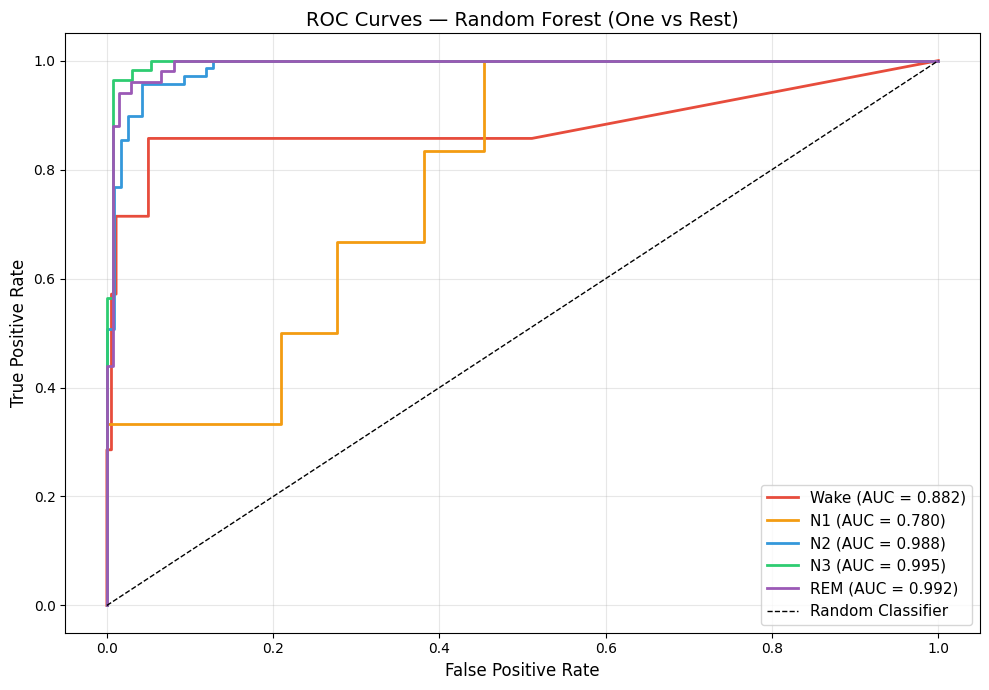

In [9]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])

plt.figure(figsize=(10, 7))

for i, (name, color) in enumerate(zip(target_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Random Forest (One vs Rest)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/rf_roc_curves.png', dpi=150)
plt.show()

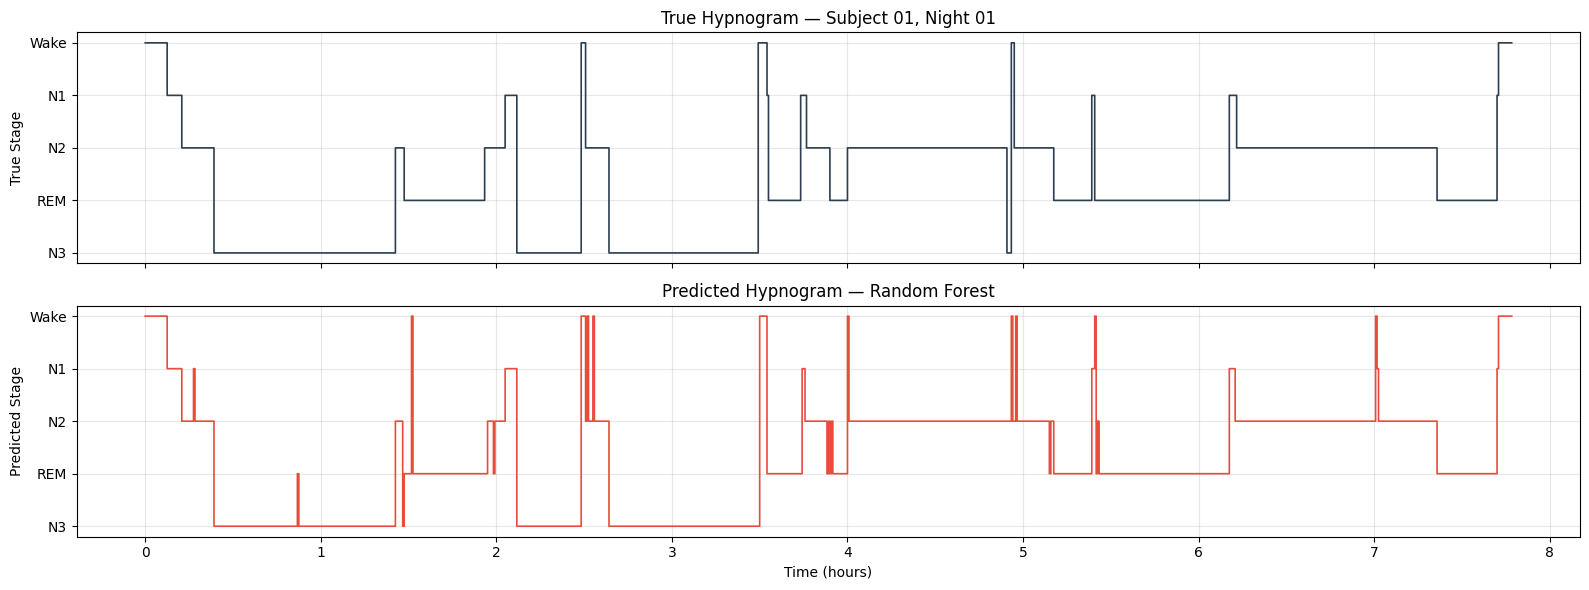

In [10]:
y_all_pred = model.predict(X)
y_all_true = y.values

# Sleep stage order for hypnogram (Wake at top, N3 at bottom)
stage_order = {0: 4, 1: 3, 2: 2, 3: 0, 4: 1}
# Wake=4(top), N1=3, REM=1, N2=2, N3=0(bottom)

true_plot  = [stage_order[s] for s in y_all_true]
pred_plot  = [stage_order[s] for s in y_all_pred]
time_hours = [i * 30 / 3600 for i in range(len(y_all_true))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

ax1.step(time_hours, true_plot, where='post', color='#2c3e50', linewidth=1.2)
ax1.set_yticks([0, 1, 2, 3, 4])
ax1.set_yticklabels(['N3', 'REM', 'N2', 'N1', 'Wake'])
ax1.set_ylabel('True Stage')
ax1.set_title('True Hypnogram — Subject 01, Night 01')
ax1.grid(True, alpha=0.3)

ax2.step(time_hours, pred_plot, where='post', color='#e74c3c', linewidth=1.2)
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(['N3', 'REM', 'N2', 'N1', 'Wake'])
ax2.set_ylabel('Predicted Stage')
ax2.set_xlabel('Time (hours)')
ax2.set_title('Predicted Hypnogram — Random Forest')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/rf_hypnogram.png', dpi=150)
plt.show()

In [8]:
print("="*24)
print("PER CLASS AUC-ROC SCORES")
print("="*24)

for i, name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"{name:>6}: {roc_auc:.4f}")

macro_auc = roc_auc_score(y_test_bin, y_prob,
                           multi_class='ovr', average='macro')
print(f"\nMacro AUC: {macro_auc:.4f}")

PER CLASS AUC-ROC SCORES
  Wake: 0.8817
    N1: 0.7799
    N2: 0.9878
    N3: 0.9955
   REM: 0.9924

Macro AUC: 0.9275


In [12]:
from sklearn.metrics import precision_score, recall_score

print("\n" + "="*50)
print("COMPLETE RESULTS SUMMARY — RANDOM FOREST BASELINE")
print("="*50)

metrics = {
    'Accuracy':     round((y_pred == y_test).mean(), 4),
    'Macro F1':     round(f1_score(y_test, y_pred, average='macro'), 4),
    'Weighted F1':  round(f1_score(y_test, y_pred, average='weighted'), 4),
    'Macro AUC-ROC':round(roc_auc_score(y_test_bin, y_prob,
                          multi_class='ovr', average='macro'), 4),
    'Cohen Kappa':  round(cohen_kappa_score(y_test, y_pred), 4),
}

for k, v in metrics.items():
    print(f"{k:>15}: {v}")

results_df = pd.DataFrame([metrics])
results_df.insert(0, 'Model', 'Random Forest')
results_df.to_csv('../reports/baseline_results.csv', index=False)
print("\nSaved to baseline_results.csv")


COMPLETE RESULTS SUMMARY — RANDOM FOREST BASELINE
       Accuracy: 0.9144
       Macro F1: 0.7853
    Weighted F1: 0.9112
  Macro AUC-ROC: 0.9275
    Cohen Kappa: 0.878

Saved to baseline_results.csv


In [13]:
errors = pd.DataFrame({
    'true':      y_test.values,
    'predicted': y_pred
})
errors = errors[errors['true'] != errors['predicted']]
errors['true_name'] = errors['true'].map(label_map)
errors['pred_name'] = errors['predicted'].map(label_map)

print(f"Total errors: {len(errors)} out of {len(y_test)} test samples")
print(f"Error rate: {len(errors)/len(y_test)*100:.1f}%\n")

print("Most common mistakes:")
mistake_counts = errors.groupby(
    ['true_name', 'pred_name']
).size().sort_values(ascending=False)
print(mistake_counts)

Total errors: 16 out of 187 test samples
Error rate: 8.6%

Most common mistakes:
true_name  pred_name
N1         N2           2
           REM          2
N2         Wake         2
           REM          2
           N3           1
           N1           1
N3         N2           1
           REM          1
REM        N2           1
           Wake         1
Wake       N2           1
           N3           1
dtype: int64


In [17]:
import os

files_to_check = [
    '../reports/rf_roc_curves.png',
    '../reports/rf_hypnogram.png',
    '../reports/baseline_results.csv',
    '../data/processed/subject_01/night_1/rf_confusion_matrix.png',
    '../data/processed/subject_01/night_1/rf_feature_importance.png',
    '../data/processed/subject_01/night_1/features.csv',
    '../data/processed/subject_01/night_1/aligned_data.pkl',
]

print("FILE CHECKLIST:")
for f in files_to_check:
    status = "✅" if os.path.exists(f) else "❌ MISSING"
    print(f"{status} {f.split('/')[-1]}")

FILE CHECKLIST:
✅ rf_roc_curves.png
✅ rf_hypnogram.png
✅ baseline_results.csv
✅ rf_confusion_matrix.png
✅ rf_feature_importance.png
✅ features.csv
✅ aligned_data.pkl
